# Priprema teksta: tokeni, rečnik i nizovi

Sveska prikazuje kako se od SMS teksta dobijaju ID-jevi tokena, dopunjeni niz i maska. Postupci su u `src/`, a analize rečnika i dužina koriste samo trening skup.

## Primer dodeljivanja ID-jeva tokenima

U ovim izmišljenim porukama `free` i `now` se pojavljuju po dva puta. Ostali tokeni se pojavljuju po jednom. Rečnik sortira tokene prvo po učestalosti, a pri izjednačenju abecedno. Zato su ID-jevi ponovljivi, ali nisu mera značenja reči.

In [1]:
from collections import Counter
from pathlib import Path
import sys

import pandas as pd

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.tokenization import tokenize_sms
from src.vocabulary import build_vocabulary, encode_sms

examples = ["Free prize now!", "Free entry now."]
toy_vocabulary = build_vocabulary(examples)
frequencies = Counter(token for message in examples for token in tokenize_sms(message))
pd.DataFrame(
    {"token": list(toy_vocabulary),
     "učestalost": [frequencies.get(token, 0) for token in toy_vocabulary],
     "ID": list(toy_vocabulary.values())}
)

,token,učestalost,ID
0,<PAD>,0,0
1,<UNK>,0,1
2,free,2,2
3,now,2,3
4,!,1,4
5,.,1,5
6,entry,1,6
7,prize,1,7


`<PAD>` uvek dobija ID `0` i kasnije će popunjavati kraće poruke. `<UNK>` ima ID `1`, koji se dodeljuje tokenima nepoznatim rečniku. Nijedan od ta dva ID-ja nije nasumičan.

In [2]:
message = "Free offer!"
pd.DataFrame({"token": tokenize_sms(message), "ID": encode_sms(message, toy_vocabulary)})

,token,ID
0,free,2
1,offer,1
2,!,4


U prethodnoj tabeli `offer` ima ID `1`, jer ga nema u dve trening poruke iz primera. Rečnik se **ne proširuje** kada obrađujemo novu poruku.

## Rečnik iz pravog trening skupa

Rečnik se gradi iz `sms_train.csv`, bez izdvojenog `sms_test.csv`. Tokom unakrsne validacije pravi se zaseban rečnik iz trening dela svakog fold-a.

In [3]:
train = pd.read_csv(project_root / "data" / "processed" / "sms_train.csv")
vocabulary = build_vocabulary(train["text"])
print("Trening poruka:", len(train))
print("Tokena u rečniku, zajedno sa <PAD> i <UNK>:", len(vocabulary))
print("Primer poruke:", train.loc[0, "text"])
tokens = tokenize_sms(train.loc[0, "text"])
ids = encode_sms(train.loc[0, "text"], vocabulary)
pd.DataFrame({"token": tokens, "ID": ids}).head(12)

Trening poruka: 4127
Tokena u rečniku, zajedno sa <PAD> i <UNK>: 7842
Primer poruke: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


,token,ID
0,go,63
1,until,578
2,jurong,5673
3,point,856
4,",",6
5,crazy,649
6,.,2
7,.,2
8,available,647
9,only,85


## Koji se tokeni često pojavljuju u svakoj klasi?

Grafikon broji **poruke koje sadrže token**, bez višestrukog brojanja istog tokena unutar poruke. Prikazane su reči od bar tri slova i njihov udeo unutar svake klase, jer `ham` i `spam` nemaju jednak broj poruka. To nije ručno zadato pravilo klasifikacije. Učestao token sam po sebi ne dokazuje da dobro razlikuje klase.

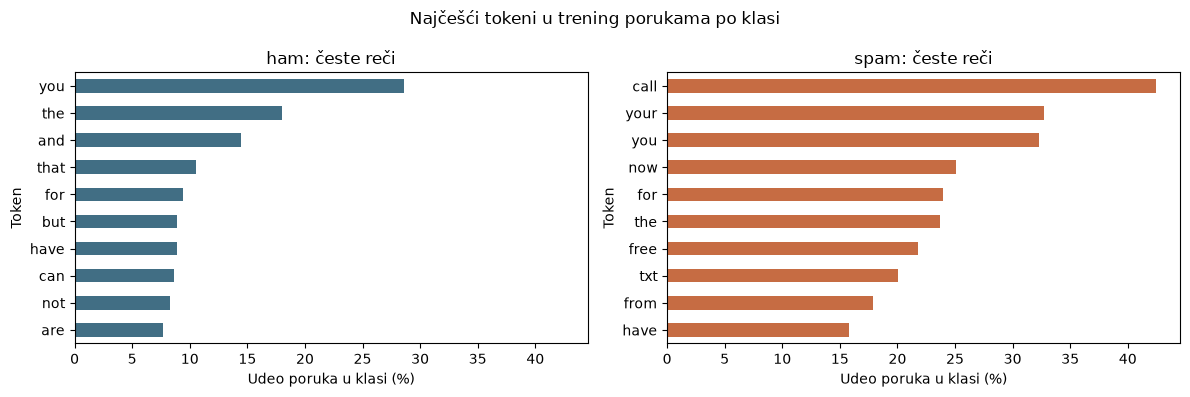

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, (label, color) in zip(axes, [('ham', '#416e84'), ('spam', '#c66c43')]):
    messages = train.loc[train['label'].eq(label), 'text']
    appearances = Counter(
        token for message in messages
        for token in sorted(set(tokenize_sms(message)))
        if token.isalpha() and len(token) >= 3
    )
    top = pd.Series(dict(appearances.most_common(10))).sort_values()
    (top / len(messages) * 100).plot.barh(ax=ax, color=color)
    ax.set(title=f'{label}: česte reči', xlabel='Udeo poruka u klasi (%)', ylabel='Token')
fig.suptitle('Najčešći tokeni u trening porukama po klasi')
fig.tight_layout()
plt.show()

## Dopuna, skraćivanje i maska

`<UNK>` je nepoznat stvarni token, dok `<PAD>` dopunjava kraće poruke. Maska `True` stoji samo na dopunskim pozicijama.

In [5]:
from src.sequences import DEFAULT_MAX_LENGTH, encode_and_pad

message = "Free offer!"
input_ids, padding_mask = encode_and_pad(message, toy_vocabulary, max_length=6)
tokens = tokenize_sms(message)
pd.DataFrame({
    "pozicija": range(6),
    "token": tokens + ["<PAD>"] * (6 - len(tokens)),
    "ID": input_ids,
    "padding maska": padding_mask,
})

,pozicija,token,ID,padding maska
0,0,free,2,False
1,1,offer,1,False
2,2,!,4,False
3,3,<PAD>,0,True
4,4,<PAD>,0,True
5,5,<PAD>,0,True


`<UNK> = 1` i `<PAD> = 0` imaju različite uloge. `offer` je stvarni deo poruke koji rečnik ne poznaje, zato maska za njega ostaje `False`. Samo dodate nule imaju `True`.

## Duga poruka

Ako poruka ima više tokena od zadate dužine, ostaje prvih `max_length`. Nema dopune, pa su sve vrednosti maske `False`. U primeru je maksimalna dužina 5 da bi se skraćivanje videlo.

In [6]:
long_message = "Free prize now! Free entry now."
short_ids, short_mask = encode_and_pad(long_message, toy_vocabulary, max_length=5)
print("Svi tokeni:", tokenize_sms(long_message))
print("Sačuvani ID-jevi:", short_ids)
print("Maska:", short_mask)

Svi tokeni: ['free', 'prize', 'now', '!', 'free', 'entry', 'now', '.']
Sačuvani ID-jevi: [2, 7, 3, 4, 2]
Maska: [False, False, False, False, False]


## Zašto je granica 128 tokena?

Izabrana granica je 128 tokena. Na trening skupu proverava se koliko bi poruka bilo skraćeno; izdvojeni test ostaje po strani.

In [7]:
lengths = train["text"].map(lambda text: len(tokenize_sms(text)))
pd.DataFrame({
    "mera": ["broj poruka", "medijana tokena", "95. percentil", "najduža poruka", "poruka dužih od 128"],
    "vrednost": [len(train), int(lengths.median()), int(lengths.quantile(0.95)), int(lengths.max()), int((lengths > DEFAULT_MAX_LENGTH).sum())],
})

,mera,vrednost
0,broj poruka,4127
1,medijana tokena,16
2,95. percentil,43
3,najduža poruka,224
4,poruka dužih od 128,4


### Raspodela dužine poruka u tokenima

Dužine su izračunate funkcijom `tokenize_sms`, istom tokenizacijom koju koristi model. Zato ne moraju odgovarati broju reči razdvojenih razmakom. Uspravna linija označava granicu od 128 tokena; poruke desno od nje se skraćuju. Radi preglednosti osa se završava malo iza granice; duže poruke su i dalje uračunate u broj ispod grafikona.

Poruke duže od 128 tokena: 4
Poruke izvan prikazanog opsega: 4


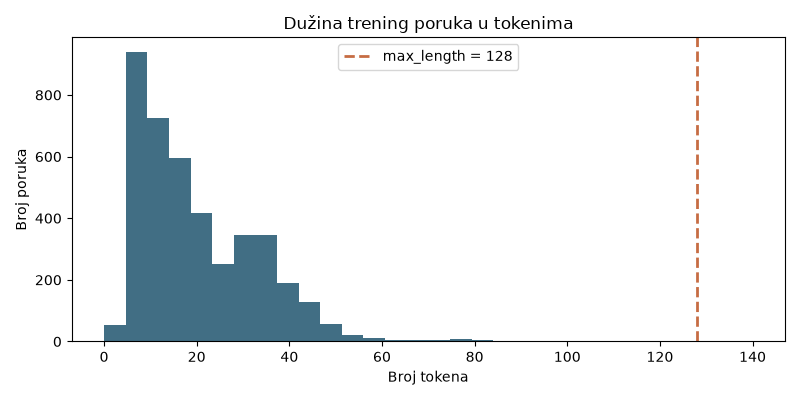

In [8]:
limit = max(DEFAULT_MAX_LENGTH + 12, int(lengths.quantile(0.99)) + 1)
visible = lengths[lengths <= limit]
print('Poruke duže od 128 tokena:', int((lengths > DEFAULT_MAX_LENGTH).sum()))
print('Poruke izvan prikazanog opsega:', int((lengths > limit).sum()))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(visible, bins=30, range=(0, limit), color='#416e84')
ax.axvline(DEFAULT_MAX_LENGTH, color='#c66c43', linestyle='--', linewidth=2, label='max_length = 128')
ax.set(title='Dužina trening poruka u tokenima', xlabel='Broj tokena', ylabel='Broj poruka')
ax.legend()
plt.tight_layout()
plt.show()

**Dalje:** PyTorch `SMSDataset` pretvara ove liste u tenzore, a `DataLoader` ih spaja u batch.